## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", 100)


In [4]:
df = pd.read_csv("sample_data.csv")
df

,postal_code_distance,zip_difference,entry_mode_same_count_24h,velocity_total_txn_48h,velocity_amount_24h,mcc_same_amount_24h,mcc_same_count_24h,auth_count_24h,atc_chip_use_count,atc_host_use_count,minutes_since_last_auth,mobile_zip_distance_6m,merchant_category_code,previous_merchant_category_code,region_indicator,previous_region_risk_indicator,merchant_terminal_capability_code,entry_mode_code,previous_entry_mode_code,keyed_swiped_code,cvv_outcome_code,ecommerce_outcome_code,arqc_result_code,ecommerce_indicator_code,is_fraud
0,131.0,7.0,2,506.57,454.09,41.68,4,6,8692,8691,39.0,65.0,4897,4897,5,5,5,5,5,S,9,2,9,21,0
1,102.0,27.0,9,80.40,59.75,38.85,1,4,1036,1036,4.0,85.0,8402,8402,5,5,6,5,7,M,9,2,9,8,0
2,6.0,4.0,2,254.69,125.80,119.25,0,8,4454,4455,330.0,76.0,6229,6229,3,0,2,5,5,U,9,8,5,11,0
3,174.0,8.0,3,698.85,143.34,56.64,1,6,9966,9964,88.0,26.0,7692,8326,1,5,5,1,90,M,9,7,9,5,0
4,55555.0,2.0,1,713.03,81.54,367.06,1,4,7525,7523,169.0,183.0,7079,7079,1,5,2,91,7,9,9,7,7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,71.0,51.0,0,271.20,142.03,28.51,4,2,5924,5925,458.0,409.0,6132,4484,5,5,6,0,0,X,8,9,9,11,0
49996,239.0,19.0,1,321.44,199.86,224.98,1,2,2406,2404,169.0,167.0,6485,9546,0,2,6,7,7,E,9,4,9,0,0
49997,39.0,10.0,0,50.52,90.21,27.42,1,5,861,862,7.0,60.0,7411,9797,2,5,6,5,5,X,9,7,9,11,0
49998,15.0,81.0,2,241.50,186.94,57.94,1,7,9768,9769,82.0,198.0,4524,4524,5,5,1,7,7,S,9,8,9,21,0


In [5]:
NUMERICAL_FEATURES = [
    "postal_code_distance",
    "zip_difference",
    "entry_mode_same_count_24h",
    "velocity_total_txn_48h",
    "velocity_amount_24h",
    "mcc_same_amount_24h",
    "mcc_same_count_24h",
    "auth_count_24h",
    "atc_chip_use_count",
    "atc_host_use_count",
    "minutes_since_last_auth",
    "mobile_zip_distance_6m",
]

CATEGORICAL_FEATURES = [
    "merchant_category_code",
    "previous_merchant_category_code",
    "region_indicator",
    "previous_region_risk_indicator",
    "merchant_terminal_capability_code",
    "entry_mode_code",
    "previous_entry_mode_code",
    "keyed_swiped_code",
    "cvv_outcome_code",
    "ecommerce_outcome_code",
    "arqc_result_code",
    "ecommerce_indicator_code",
]

TARGET = "is_fraud"

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES
print(f"{len(NUMERICAL_FEATURES)} numerical features, {len(CATEGORICAL_FEATURES)} categorical features")

12 numerical features, 12 categorical features


## 4. Exploratory Data Analysis

Quick checks on class balance, missingness, distributions, and how key
fields relate to the fraud label.


In [6]:
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

fraud_rate = df[TARGET].mean()
print(f"\nOverall fraud rate: {fraud_rate:.3%}")


Missing values per column:
postal_code_distance         0
zip_difference               0
entry_mode_same_count_24h    0
velocity_total_txn_48h       0
velocity_amount_24h          0
mcc_same_amount_24h          0
mcc_same_count_24h           0
auth_count_24h               0
atc_chip_use_count           0
atc_host_use_count           0
dtype: int64

Overall fraud rate: 1.994%


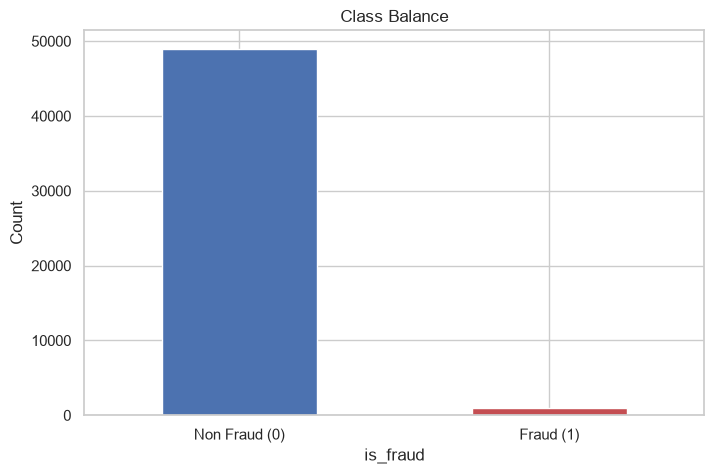

In [8]:
fig, ax = plt.subplots()
df[TARGET].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Non Fraud (0)", "Fraud (1)"], rotation=0)
ax.set_title("Class Balance")
ax.set_ylabel("Count")
plt.show()


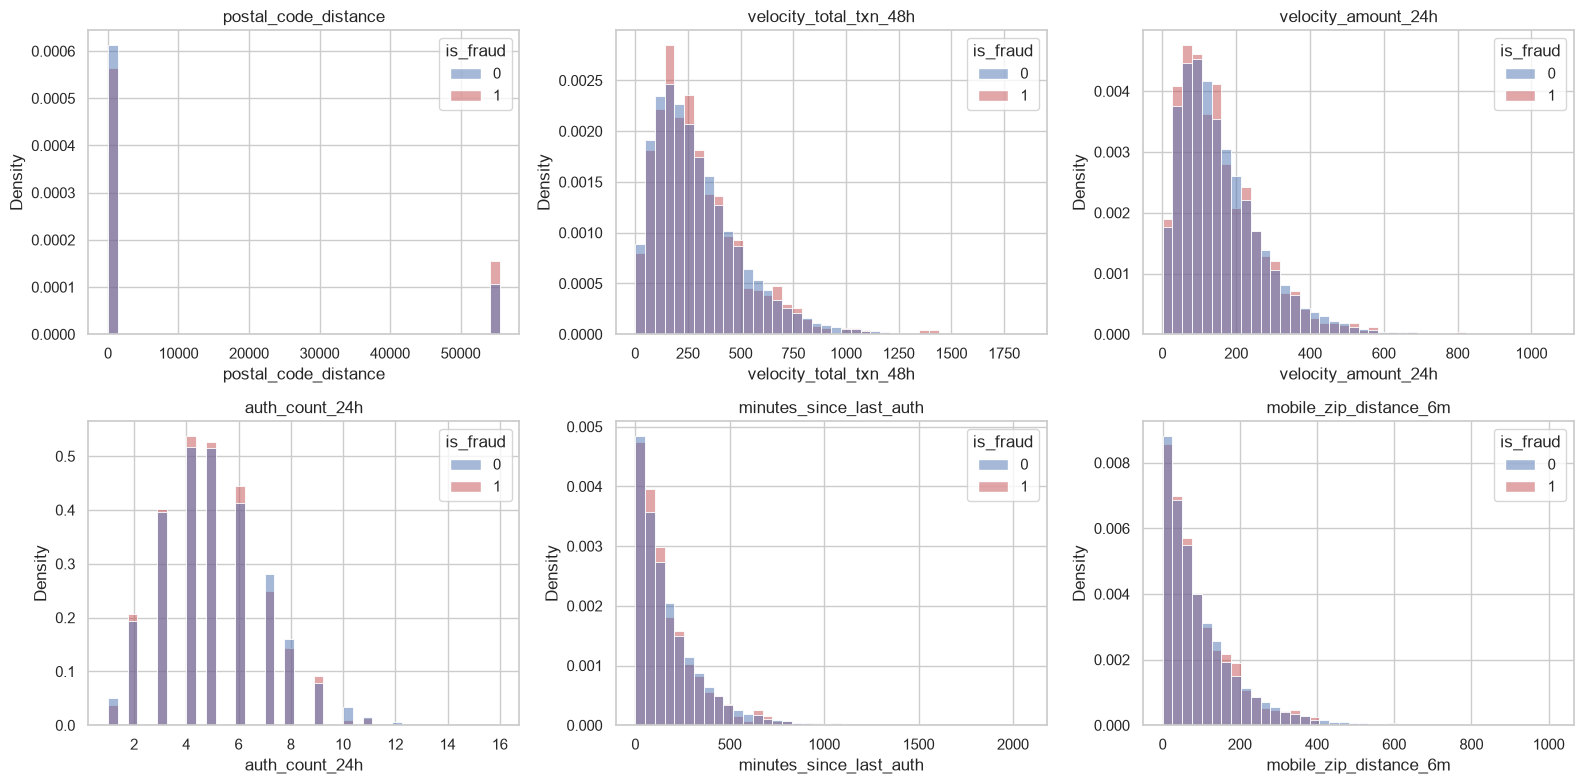

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num_subset = ["postal_code_distance", "velocity_total_txn_48h", "velocity_amount_24h",
              "auth_count_24h", "minutes_since_last_auth", "mobile_zip_distance_6m"]

for ax, col in zip(axes.ravel(), num_subset):
    sns.histplot(data=df, x=col, hue=TARGET, bins=40, stat="density",
                 common_norm=False, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_title(col)

plt.tight_layout()
plt.show()


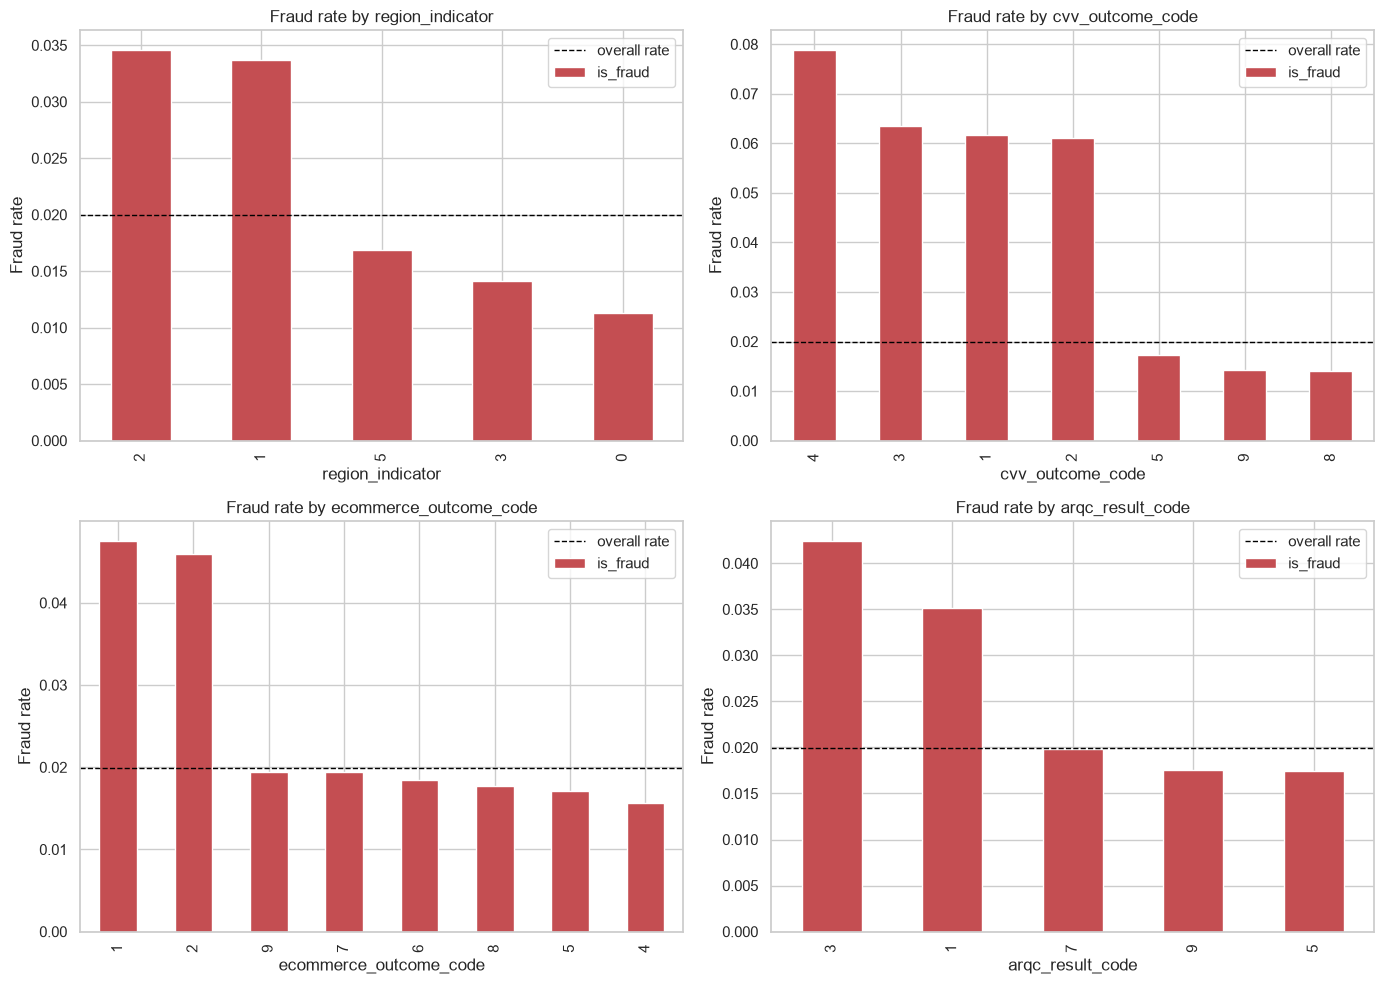

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_subset = ["region_indicator", "cvv_outcome_code", "ecommerce_outcome_code", "arqc_result_code"]

for ax, col in zip(axes.ravel(), cat_subset):
    rate_by_cat = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    rate_by_cat.plot(kind="bar", ax=ax, color="#C44E52")
    ax.axhline(fraud_rate, color="black", linestyle="--", linewidth=1, label="overall rate")
    ax.set_title(f"Fraud rate by {col}")
    ax.set_ylabel("Fraud rate")
    ax.legend()

plt.tight_layout()
plt.show()

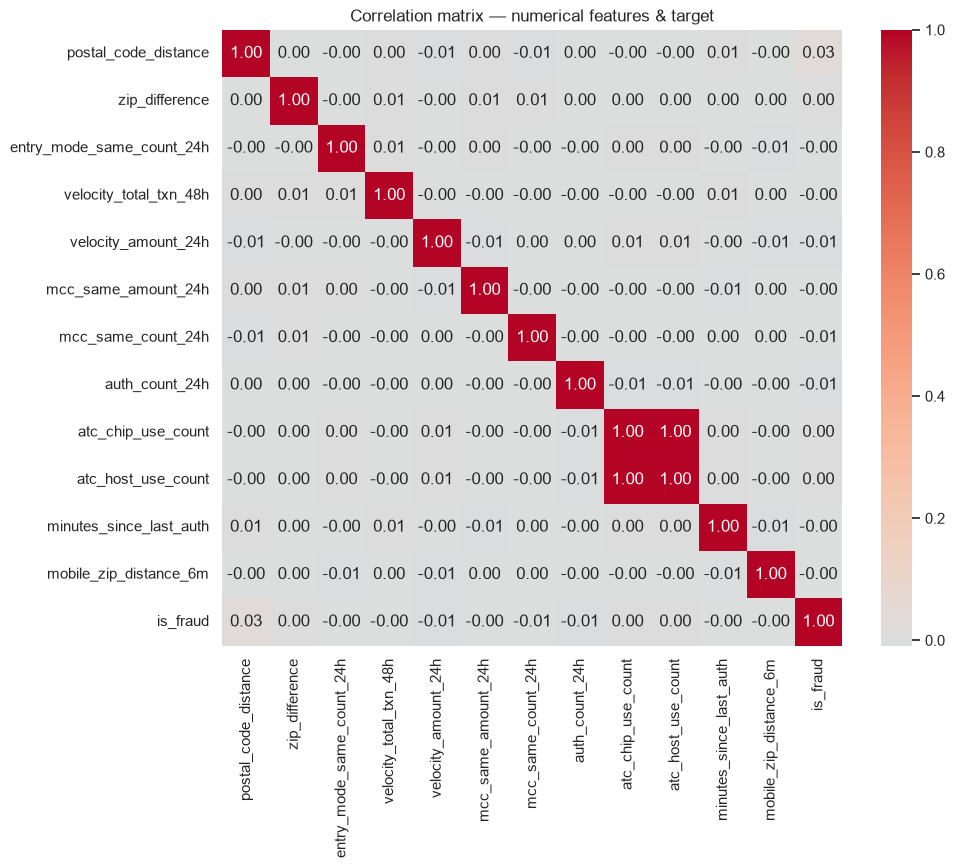

In [11]:
corr = df[NUMERICAL_FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix — numerical features & target")
plt.show()

## 5. Preprocessing


In [14]:
import xgboost as xgb
print(xgb.__version__)

3.4.1


In [18]:
df_model = df.copy()

# Categorical features: convert to pandas 'category' dtype, NOT string + one-hot
df_model[CATEGORICAL_FEATURES] = df_model[CATEGORICAL_FEATURES].astype("category")
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   postal_code_distance               50000 non-null  float64 
 1   zip_difference                     50000 non-null  float64 
 2   entry_mode_same_count_24h          50000 non-null  int64   
 3   velocity_total_txn_48h             50000 non-null  float64 
 4   velocity_amount_24h                50000 non-null  float64 
 5   mcc_same_amount_24h                50000 non-null  float64 
 6   mcc_same_count_24h                 50000 non-null  int64   
 7   auth_count_24h                     50000 non-null  int64   
 8   atc_chip_use_count                 50000 non-null  int64   
 9   atc_host_use_count                 50000 non-null  int64   
 10  minutes_since_last_auth            50000 non-null  float64 
 11  mobile_zip_distance_6m             50000 non-null  f

In [ ]:
X = df_model[NUMERICAL_FEATURES + CATEGORICAL_FEATURES]
y = df_model[TARGET]

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# Baseline: group-safe, but NOT time-safe
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in sgkf.split(df_model, y, groups=df_model["account_identifier"]):
    df_train, df_test = df_model.iloc[train_idx], df_model.iloc[test_idx]
    break

In [ ]:

model = xgb.XGBClassifier(   
    tree_method="hist",
    enable_categorical=True,
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric="logloss",   # or "rmse"/"mae" for regression
)

print(df_model[CATEGORICAL_FEATURES].dtypes)  # should show 'category' for each

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(model.get_booster().feature_types)      # should show 'c' for categorical columns, 'q'/'float' for numeric

## 6. Train / Test Split

A stratified split preserves the (low) fraud rate in both sets, which
matters for an imbalanced classification problem like this one.


In [11]:
X = df_model[ALL_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, fraud rate {y_train.mean():.3%}")
print(f"Test:  {X_test.shape}, fraud rate {y_test.mean():.3%}")


Train: (37500, 24), fraud rate 1.995%
Test:  (12500, 24), fraud rate 1.992%


## 7. Baseline Model — Logistic Regression

`class_weight="balanced"` compensates for the class imbalance without
resampling. This gives a simple, interpretable baseline to compare
tree-based models against.


In [12]:
logreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)
y_proba_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")
print(f"PR-AUC (avg precision): {average_precision_score(y_test, y_proba_lr):.3f}")


              precision    recall  f1-score   support

           0      0.986     0.724     0.835     12251
           1      0.036     0.506     0.067       249

    accuracy                          0.720     12500
   macro avg      0.511     0.615     0.451     12500
weighted avg      0.967     0.720     0.820     12500

ROC-AUC: 0.651
PR-AUC (avg precision): 0.049


## 8. Random Forest Classifier

A tree ensemble that handles nonlinear interactions between features (e.g.
region risk combined with a failed CVV check) without manual feature
crosses.


In [13]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")
print(f"PR-AUC (avg precision): {average_precision_score(y_test, y_proba_rf):.3f}")


              precision    recall  f1-score   support

           0      0.985     0.909     0.945     12251
           1      0.062     0.297     0.103       249

    accuracy                          0.897     12500
   macro avg      0.523     0.603     0.524     12500
weighted avg      0.966     0.897     0.929     12500

ROC-AUC: 0.665
PR-AUC (avg precision): 0.046


## 9. Gradient Boosting Classifier

Gradient-boosted trees often edge out Random Forest on tabular fraud
problems. (Swap in XGBoost/LightGBM here if those packages are available in
your environment — the pipeline structure stays identical.)


In [14]:
gb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
    )),
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)
y_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.3f}")
print(f"PR-AUC (avg precision): {average_precision_score(y_test, y_proba_gb):.3f}")


              precision    recall  f1-score   support

           0      0.980     0.998     0.989     12251
           1      0.033     0.004     0.007       249

    accuracy                          0.978     12500
   macro avg      0.507     0.501     0.498     12500
weighted avg      0.961     0.978     0.969     12500

ROC-AUC: 0.694
PR-AUC (avg precision): 0.048


## 10. Model Comparison & Evaluation

For imbalanced fraud problems, **ROC-AUC alone can be misleading** — the
Precision-Recall curve and PR-AUC are usually more informative, since they
focus on how well the model finds the rare positive (fraud) class without
flooding investigators with false positives.


In [15]:
results = {
    "Logistic Regression": (y_proba_lr, roc_auc_score(y_test, y_proba_lr), average_precision_score(y_test, y_proba_lr)),
    "Random Forest": (y_proba_rf, roc_auc_score(y_test, y_proba_rf), average_precision_score(y_test, y_proba_rf)),
    "Gradient Boosting": (y_proba_gb, roc_auc_score(y_test, y_proba_gb), average_precision_score(y_test, y_proba_gb)),
}

summary = pd.DataFrame(
    {name: {"ROC-AUC": vals[1], "PR-AUC": vals[2]} for name, vals in results.items()}
).T.sort_values("PR-AUC", ascending=False)
summary


,ROC-AUC,PR-AUC
Logistic Regression,0.651159,0.049163
Gradient Boosting,0.694101,0.048189
Random Forest,0.664974,0.046344


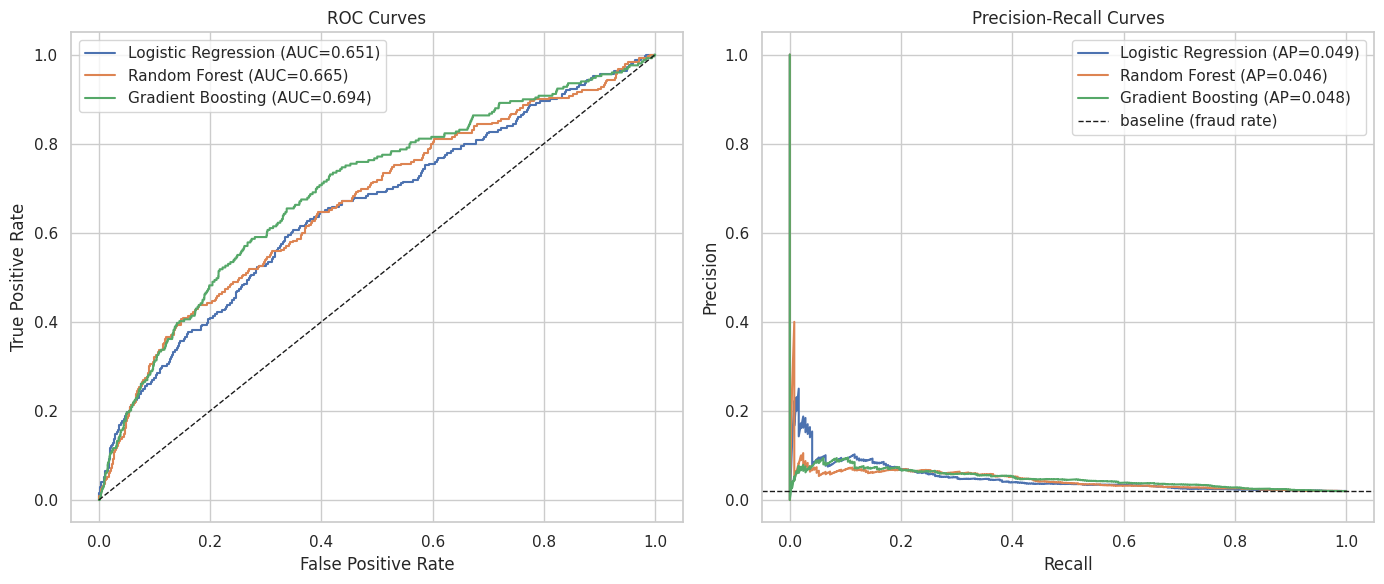

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, (proba, roc_auc, pr_auc) in results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={pr_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

axes[1].axhline(y_test.mean(), color="k", linestyle="--", linewidth=1, label="baseline (fraud rate)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend()

plt.tight_layout()
plt.show()


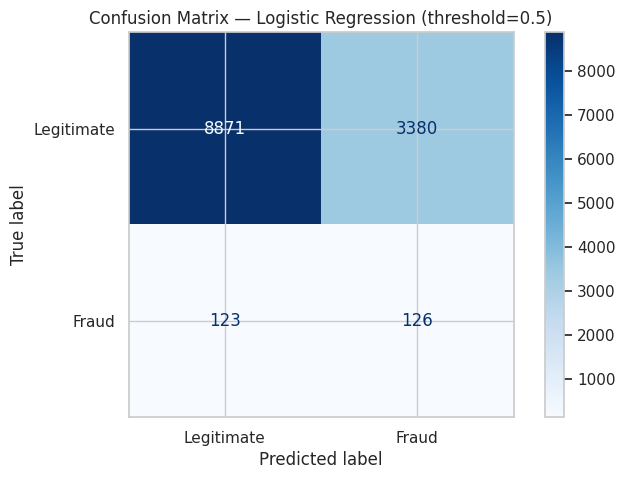

In [17]:
best_name = summary.index[0]
best_proba = results[best_name][0]
best_pred = (best_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_name} (threshold=0.5)")
plt.show()


## 11. Feature Importance

Which fields drive the model's fraud predictions? This uses the
tree-based feature importances from the best-performing ensemble model.


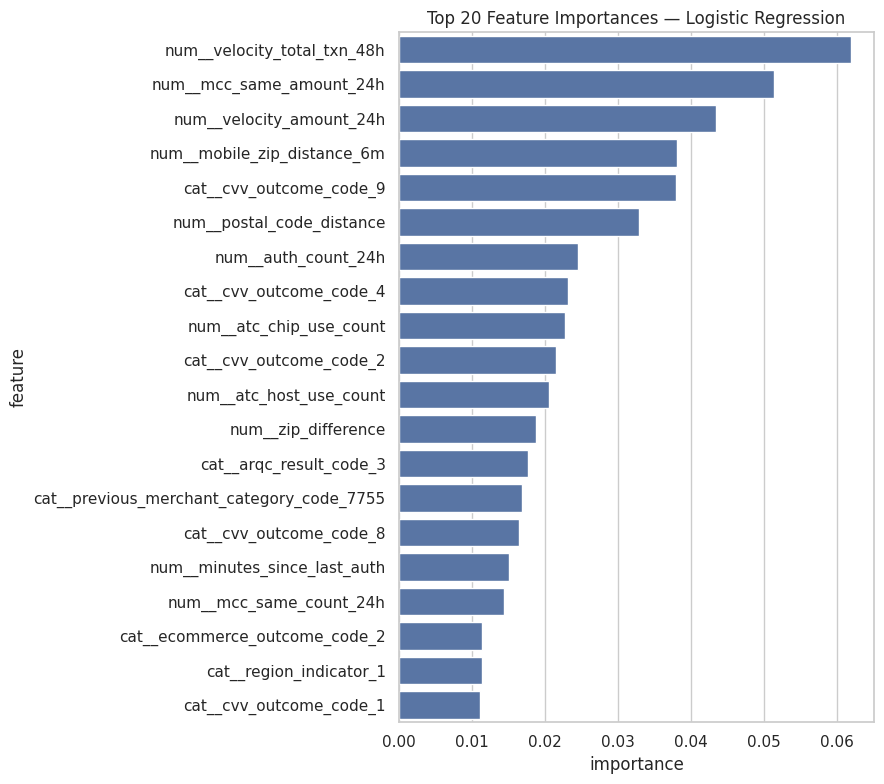

In [18]:
best_pipeline = rf_pipeline if best_name == "Random Forest" else gb_pipeline

feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = best_pipeline.named_steps["model"].feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=feat_imp, y="feature", x="importance", ax=ax, color="#4C72B0")
ax.set_title(f"Top 20 Feature Importances — {best_name}")
plt.tight_layout()
plt.show()


## 12. Conclusions & Next Steps

- This notebook is a **complete, runnable pipeline** — synthetic data in,
  trained/evaluated fraud classifiers out — built entirely around the fields
  from the data dictionary you provided.
- **Swap in real data:** replace the `generate_synthetic_data()` call in
  section 3 with your actual transaction extract (same column names), and
  everything downstream should run as-is.
- **Resolve the open questions** noted in section 2 with your data owner
  before trusting real-data results — especially the definition of
  "cardholder location" for postal-distance fields, and whether velocity/
  count fields include declined authorizations.
- **Class imbalance:** real-world fraud rates are often far lower than the
  2% used here (sometimes <0.1%). At that scale, consider techniques such as
  SMOTE/undersampling, cost-sensitive learning, or anomaly-detection
  approaches (Isolation Forest, autoencoders) alongside supervised
  classification.
- **Threshold tuning:** the 0.5 decision threshold used above is rarely
  optimal for fraud; tune it against a business cost matrix (cost of a
  missed fraud vs. cost of a false positive / customer friction).
- **Temporal validation:** for production fraud models, prefer a
  time-based train/test split (train on earlier transactions, test on
  later ones) over a random split, since fraud patterns drift over time.
- **Feature leakage check:** verify that fields like "previous_*" and
  velocity counters are computed strictly from information available
  *before* the current authorization — not using future data.
